In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from pathlib import Path

# Verificar versin de TensorFlow
print(" TensorFlow versin:", tf.__version__)


 TensorFlow versin: 2.20.0


In [2]:
BASE_DIR = Path("../data/processed/classification_split")

TRAIN_DIR = BASE_DIR / "train"
VAL_DIR = BASE_DIR / "val"
TEST_DIR = BASE_DIR / "test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Entrenando con rutas:")
print("Train:", TRAIN_DIR)
print("Val:", VAL_DIR)
print("Test:", TEST_DIR)


Entrenando con rutas:
Train: ..\data\processed\classification_split\train
Val: ..\data\processed\classification_split\val
Test: ..\data\processed\classification_split\test


In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 1937 images belonging to 2 classes.
Found 427 images belonging to 2 classes.
Found 405 images belonging to 2 classes.


In [4]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

# Verificar versión de TensorFlow
print(f"TensorFlow version: {tf.__version__}")

# Crear el modelo base
try:
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    print("✅ MobileNetV2 creado exitosamente")
except Exception as e:
    print(f"❌ Error al crear MobileNetV2: {e}")
    print("Intentando con pesos aleatorios...")
    base_model = MobileNetV2(
        weights=None,
        include_top=False,
        input_shape=(224, 224, 3)
    )

# Congelar el modelo base
base_model.trainable = False

# Ver resumen
print("\nResumen del modelo base:")
print(f"Número de capas: {len(base_model.layers)}")
print(f"Número de parámetros totales: {base_model.count_params():,}")

TensorFlow version: 2.20.0
✅ MobileNetV2 creado exitosamente

Resumen del modelo base:
Número de capas: 154
Número de parámetros totales: 2,257,984


In [5]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Construcción del modelo final
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.0008),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
#Callbacks (early stopping + guardar mejor modelo)
# Exportacin: mejor modelo en ../models/classification/modelo_clasificador.h5
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("../models/classification/modelo_clasificador.h5",
                    save_best_only=True,
                    monitor="val_loss")
]


In [7]:
#Entrenamiento
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6796 - auc: 0.7100 - loss: 0.6595 - precision: 0.7043 - recall: 0.7952

61/61 ━━━━━━━━━━━━━━━━━━━━ 177s 3s/step - accuracy: 0.7961 - auc: 0.8638 - loss: 0.4553 - precision: 0.8093 - recall: 0.8435 - val_accuracy: 0.9602 - val_auc: 0.9850 - val_loss: 0.2197 - val_precision: 0.9474 - val_recall: 0.9832
Epoch 2/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9444 - auc: 0.9891 - loss: 0.1918 - precision: 0.9323 - recall: 0.9705

61/61 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - accuracy: 0.9633 - auc: 0.9922 - loss: 0.1613 - precision: 0.9594 - recall: 0.9775 - val_accuracy: 0.9742 - val_auc: 0.9908 - val_loss: 0.1351 - val_precision: 0.9710 - val_recall: 0.9832
Epoch 3/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9808 - auc: 0.9973 - loss: 0.1073 - precision: 0.9791 - recall: 0.9882

61/61 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.9850 - auc: 0.9979 - loss: 0.0946 - precision: 0.9848 - recall: 0.9892 - val_accuracy: 0.9719 - val_auc: 0.9930 - val_loss: 0.1089 - val_precision: 0.9669 - val_recall: 0.9832
Epoch 4/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9898 - auc: 0.9995 - loss: 0.0677 - precision: 0.9874 - recall: 0.9953

61/61 ━━━━━━━━━━━━━━━━━━━━ 212s 3s/step - accuracy: 0.9897 - auc: 0.9992 - loss: 0.0664 - precision: 0.9910 - recall: 0.9910 - val_accuracy: 0.9719 - val_auc: 0.9940 - val_loss: 0.0959 - val_precision: 0.9669 - val_recall: 0.9832
Epoch 5/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9893 - auc: 0.9997 - loss: 0.0543 - precision: 0.9900 - recall: 0.9909

...

61/61 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9974 - auc: 1.0000 - loss: 0.0142 - precision: 0.9982 - recall: 0.9973 - val_accuracy: 0.9813 - val_auc: 0.9963 - val_loss: 0.0619 - val_precision: 0.9873 - val_recall: 0.9790
Epoch 17/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.9985 - auc: 1.0000 - loss: 0.0133 - precision: 0.9991 - recall: 0.9982 - val_accuracy: 0.9859 - val_auc: 0.9964 - val_loss: 0.0641 - val_precision: 0.9957 - val_recall: 0.9790
Epoch 18/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9969 - auc: 1.0000 - loss: 0.0144 - precision: 0.9980 - recall: 0.9964

61/61 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.9979 - auc: 1.0000 - loss: 0.0143 - precision: 0.9982 - recall: 0.9982 - val_accuracy: 0.9836 - val_auc: 0.9963 - val_loss: 0.0610 - val_precision: 0.9873 - val_recall: 0.9832
Epoch 19/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9964 - auc: 1.0000 - loss: 0.0151 - precision: 0.9991 - recall: 0.9947

61/61 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.9974 - auc: 1.0000 - loss: 0.0131 - precision: 0.9982 - recall: 0.9973 - val_accuracy: 0.9836 - val_auc: 0.9965 - val_loss: 0.0595 - val_precision: 0.9873 - val_recall: 0.9832
Epoch 20/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9981 - auc: 1.0000 - loss: 0.0129 - precision: 0.9979 - recall: 0.9988

61/61 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9985 - auc: 1.0000 - loss: 0.0112 - precision: 0.9982 - recall: 0.9991 - val_accuracy: 0.9813 - val_auc: 0.9965 - val_loss: 0.0592 - val_precision: 0.9832 - val_recall: 0.9832
Epoch 21/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9979 - auc: 1.0000 - loss: 0.0123 - precision: 0.9982 - recall: 0.9982 - val_accuracy: 0.9813 - val_auc: 0.9966 - val_loss: 0.0596 - val_precision: 0.9873 - val_recall: 0.9790
Epoch 22/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9979 - auc: 1.0000 - loss: 0.0125 - precision: 1.0000 - recall: 0.9964 - val_accuracy: 0.9742 - val_auc: 0.9964 - val_loss: 0.0610 - val_precision: 0.9671 - val_recall: 0.9874
Epoch 23/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0098 - precision: 1.0000 - recall: 1.0000

61/61 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0090 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9813 - val_auc: 0.9966 - val_loss: 0.0579 - val_precision: 0.9873 - val_recall: 0.9790
Epoch 24/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.9979 - auc: 0.9999 - loss: 0.0123 - precision: 0.9982 - recall: 0.9982 - val_accuracy: 0.9813 - val_auc: 0.9965 - val_loss: 0.0615 - val_precision: 0.9873 - val_recall: 0.9790
Epoch 25/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.9995 - auc: 1.0000 - loss: 0.0092 - precision: 1.0000 - recall: 0.9991 - val_accuracy: 0.9813 - val_auc: 0.9965 - val_loss: 0.0628 - val_precision: 0.9873 - val_recall: 0.9790
Epoch 26/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.9990 - auc: 1.0000 - loss: 0.0089 - precision: 1.0000 - recall: 0.9982 - val_accuracy: 0.9813 - val_auc: 0.9966 - val_loss: 0.0614 - val_precision: 0.9873 - val_recall: 0.9790
Epoch 27/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 147s 

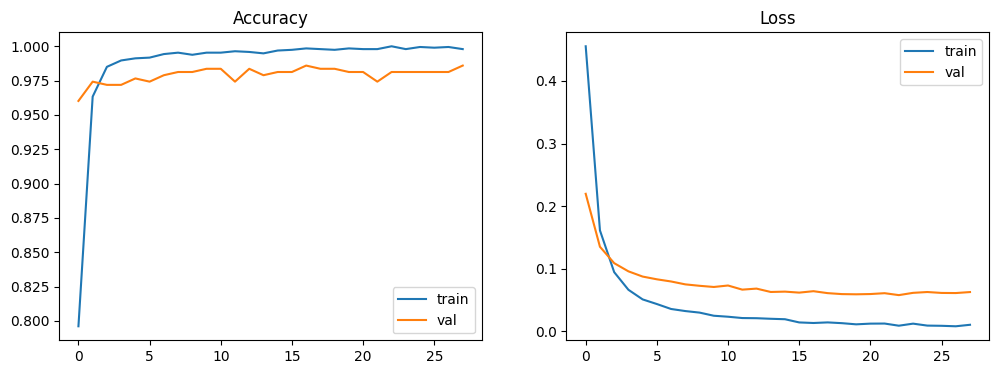

In [8]:
#Gráficos de accuracy y loss
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.title("Loss")

plt.show()


In [9]:
#Evaluaci?n en test
results = model.evaluate(test_gen, return_dict=True)
print("Test Accuracy:", results.get("accuracy"))
print("Test Metrics:", results)


13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9877 - auc: 0.9999 - loss: 0.0207 - precision: 0.9795 - recall: 1.0000
Test Accuracy: 0.9876543283462524
Test Metrics: {'accuracy': 0.9876543283462524, 'auc': 0.9999496340751648, 'loss': 0.020687788724899292, 'precision': 0.9795082211494446, 'recall': 1.0}


In [10]:
# Metricas adicionales en test
test_gen.reset()
probs = model.predict(test_gen, verbose=0).reshape(-1)
y_true = test_gen.classes
y_pred = (probs > 0.5).astype(int)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="binary", zero_division=0
)
auc = roc_auc_score(y_true, probs)
cm = confusion_matrix(y_true, y_pred)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("AUC:", auc)
print("Confusion Matrix:\n", cm)


Precision: 0.9795081967213115
Recall: 1.0
F1: 0.989648033126294
AUC: 0.9999495891515854
Confusion Matrix:
 [[161   5]
 [  0 239]]


In [11]:
# Exportacin: modelo TFLite en ../models/classification/modelo_clasificador.tflite
#Guardar modelo TFLite (para usar offline)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("../models/classification/modelo_clasificador.tflite", "wb") as f:
    f.write(tflite_model)

print("Modelo TFLite exportado")


INFO:tensorflow:Assets written to: C:\Users\Leo\AppData\Local\Temp\tmpjy5411d0\assets


INFO:tensorflow:Assets written to: C:\Users\Leo\AppData\Local\Temp\tmpjy5411d0\assets


Saved artifact at 'C:\Users\Leo\AppData\Local\Temp\tmpjy5411d0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2518402616400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2518402615824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2518402618320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2518402617936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2518402616784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2518402618512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2518402616976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2518402619088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2518402618704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2518402616592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2518402